検索済みインデックスの探索の効率化を試みたが、微妙だった。

In [31]:
from contextlib import contextmanager
import time

@contextmanager
def timer(name):
    t0 = time.time()
    yield
    print(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [32]:
from collections import deque
from pathlib import Path
from dataclasses import dataclass, field
import time
import numpy as np
from itertools import product

In [33]:
def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

def is_out_of_range(y, x, N):
    return not ((0 <= x < N) and (0 <= y < N))

# Env

In [34]:
# --------------------  #
class Env:

    def __init__(self, file_path):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2*M:]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))
        
        self.N = N
        self.M = M
        self.esp = ESP
        self.grids = GRID
        self.ans_grid = ANS_GRID
        
        self.total_oil_num = sum(len(g) for g in self.grids)
        self.score = 10 ** 9

        cnt = 0
        for x in range(N):
            for y in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size = cnt
    
        self._sum_oil = 0
        self._score = 0

        self.plus_coordinates = []
        self.queries1 = []
        self.queries2 = []
        self.fixed_board = [[None for _ in range(N)] for _ in range(N)]

    def is_ok(self):
        return self._sum_oil == self.total_oil_num
        
    def query1(self, coordinate):
        y, x = coordinate
        self._score += 1
        resp = self.ans_grid[y][x]
        self.queries1.append((coordinate, resp))
        self.fixed_board[y][x] = resp
        if resp > 0:
            self._sum_oil += resp
            self.plus_coordinates.append(coordinate)
        return resp

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for y, x in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        resp = max(0, round(rng.normal(mu, sigma)))
        self._score += 1 / np.sqrt(k)
        self.queries2.append(resp)
        return resp

    def answer(self, coordinates):
        is_ok = self.total_oil_num == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        return is_ok

In [35]:
# --------------------  #
class BFSSolver:
    """
    幅優先探索で貪欲的に確定する
    RESULT: 127.69
    """

    def __init__(self, N):
        self.N = N
        self.grid_count = [[-1 for _ in range(N)] for _ in range(N)]
        self.grid_response = [[False for _ in range(N)] for _ in range(N)]
        self.grid_distance = [[0 for _ in range(N)] for _ in range(N)]
        for x in range(N):
            for y in range(N):
                self.grid_distance[y][x] = min(x + 1, y + 1, N - x, N - y)

        self.next_grids = set()

    def update(self, coordinate, resp):
        y, x = coordinate
        self.grid_count[y][x] = resp
        self.grid_response[y][x] = True
        if resp > 0:
            for dy, dx in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                ny, nx = y + dy, x + dx
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if not self.grid_response[ny][nx]:
                    self.next_grids.add((ny, nx))
        self._update_distance(y, x)

    def get_next_search_point(self):
        while self.next_grids:
            y, x = self.next_grids.pop()
            if not self.grid_response[y][x]:
                return y, x

        return self._get_far_point_from_wall()

    def _update_distance(self, y, x):
        searched = [[False for _ in range(self.N)] for _ in range(self.N)]
        self.grid_distance[y][x] = 0
        start = [(y, x)]
        search_q = deque(start)
        while search_q:
            py, px = search_q.popleft()
            searched[py][px] = True
            if searched[py][px]:
                continue
            for dy, dx in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                ny, nx = py + dy, px + dx
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if self.grid_distance[ny][nx] == 0 or searched[ny][nx]:
                    continue
                search_q.append((ny, nx))
                self.grid_distance[ny][nx] = min(
                    self.grid_distance[ny][nx], self.grid_distance[py][px] + 1
                )

    def _get_far_point_from_wall(self):
        max_val = -(10**9)
        ret = None
        for x in range(self.N):
            for y in range(self.N):
                if self.grid_response[y][x]:
                    continue
                if self.grid_distance[y][x] > max_val:
                    max_val = self.grid_distance[y][x]
                    ret = y, x
        if ret is None:
            raise NotImplementedError("Why?")
        return ret

In [36]:
import random

class BoardSimulator:
    
    SIMULATE_NUM = 10 ** 8
    SIMULATE_TIME = 1.5

    def __init__(self, env:Env):
        self.env = env
        self._search_placement_indexes()

        self.simulate_avg_num = 0
        self.simulate_cnt = 0
    
    def _search_placement_indexes(self):
        """ 現在の確定盤面に対して配置可能なインデックスを計算する"""

        N = self.env.N
        M = self.env.M
        f_board = self.env.fixed_board
        grids = self.env.grids

        placement_indexes = {}
        coordinate_to_placement_indexes = {}
        for m in range(M):
            now_grids = grids[m]
            now_placement_indexes = []
            now_coordinate_to_placement_indexes = [[set() for _ in range(N)] for _ in range(N)]
            for y, x in product(list(range(N)), list(range(N))):
                flag = True
                for coordinate in now_grids:
                    ny, nx = y + coordinate[0], x + coordinate[1]
                    if is_out_of_range(ny, nx, N):
                        flag = False
                        break
                    if f_board[ny][nx] is None:
                        continue
                    if f_board[ny][nx] == 0:
                        flag = False
                        break
                if flag:
                    now_placement_indexes.append((y, x))
                    for coordinate in now_grids:
                        ny, nx = y + coordinate[0], x + coordinate[1]
                        now_coordinate_to_placement_indexes[ny][nx].add((y, x))

            placement_indexes[m] = now_placement_indexes
            coordinate_to_placement_indexes[m] = now_coordinate_to_placement_indexes

        self.placement_indexes = placement_indexes
        self.coordinate_to_placement_indexes = coordinate_to_placement_indexes
    
    def update(self, coordinate, resp):
        if resp == 0:
            self._update_placement_indexes(coordinate)

    def _update_placement_indexes(self, coordinate):

        M = self.env.M
        for m in range(M):
            ty, tx = coordinate
            pre_ind = self.placement_indexes[m]
            del_ind = self.coordinate_to_placement_indexes[m][ty][tx]
            self.placement_indexes[m] = list(set(pre_ind) - set(del_ind))

    def _calc_cost_from_simulated_board(self, simulated_board):

        N = self.env.N
        f_board = self.env.fixed_board

        cost = 0
        for y, x in product(list(range(N)), list(range(N))):
            if f_board[y][x] is None:
                continue

            # なぜか確定情報より増えたコストだけ計算したほうが結果が良かった。
            # v = abs(simulated_board[y][x] - f_board[y][x])
            
            v = simulated_board[y][x] - f_board[y][x]
            if v > 0:
                cost += v
            cost += v
        return cost

    def _simulate_board(self):
        """
        現在の盤面と最も一致している（コストの低い）盤面で、最も正の数である確率が高い座標を返す。

        盤面のあるインデックスが正の数である確率
        現在の盤面との乖離コスト（シミュレート盤面のある値が、現在の値より大きければ加算）
        そのコストであったときの盤面の総数
        シミュレート可能総数
        """

        start_time = time.time()

        INF = 10**9

        N = self.env.N
        M = self.env.M
        f_board = self.env.fixed_board
        grids = self.env.grids

        min_cost = INF
        same_cost_cnt = 0
        plus_count_board = [[0 for _ in range(N)] for _ in range(N)]

        for simulate_num in range(BoardSimulator.SIMULATE_NUM):
            now_board = [[0 for _ in range(N)] for _ in range(N)]
            for m in range(M):
                sampling_index = random.choice(self.placement_indexes[m])
                for y, x in grids[m]:
                    ny, nx = y + sampling_index[0], x + sampling_index[1]
                    now_board[ny][nx] += 1
            cost = self._calc_cost_from_simulated_board(now_board)

            if cost < min_cost:
                min_cost = cost
                same_cost_cnt = 0
                plus_count_board = [[0 for _ in range(N)] for _ in range(N)]
            if cost <= min_cost:
                for y, x in product(list(range(N)), list(range(N))):
                    if now_board[y][x] > 0:
                        plus_count_board[y][x] += 1
                same_cost_cnt += 1
            if time.time() - start_time > BoardSimulator.SIMULATE_TIME / N ** 2:
                # シミュレート部分に合計3秒以上かけるとまずい
                break
        self.simulate_avg_num = 1 / (1+self.simulate_cnt) * (self.simulate_cnt + simulate_num)

        max_coordinate = None
        max_cnt = -1
        for y, x in product(list(range(N)), list(range(N))):
            if f_board[y][x] is not None:
                continue
            cnt = plus_count_board[y][x]
            if cnt > max_cnt:
                max_cnt = cnt
                max_coordinate = (y, x)
        
        return max_coordinate

    def get_next_coordinate(self):
        return self._simulate_board()

# Run

In [37]:
class Evaluator:

    def __init__(self):
        self.scores = []
        self.ans_points = []
        self.board_sizes = []

    def add_result(self, score, ans_point, board_size):
        self.scores.append(score)
        self.ans_points.append(ans_point)
        self.board_sizes.append(board_size)

In [38]:
def solve(env):
    
    board_simulator = BoardSimulator(env)
    # bfs_solver = BFSSolver(env.N)

    for i in range(500):
        if env.is_ok():
            env.answer(env.plus_coordinates)
            break
        # coordinate = bfs_solver.get_next_search_point()
        # resp = env.query1(coordinate)
        # bfs_solver.update(coordinate, resp)
        coordinate = board_simulator.get_next_coordinate()
        resp = env.query1(coordinate)
        board_simulator.update(coordinate, resp)
    print(board_simulator.simulate_avg_num)

In [39]:
import random

TEST_NUM = 100
evaluator = Evaluator()

def main():
    random.seed(0)
    for test_num in range(TEST_NUM):
        env = Env(file_path = Path(f"./in/{test_num:0>4}.txt"))
        with timer("time"):
            solve(env)

        evaluator.add_result(env.score, env.ans_point_size, env.N**2)
        print(f"[{test_num+1}/{TEST_NUM}] score:{env.score}")
main()

467.0
[time] done in 1010.1 msec
[1/100] score:89
548.0
[time] done in 594.3 msec
[2/100] score:54
974.0
[time] done in 896.4 msec
[3/100] score:58
545.0
[time] done in 813.1 msec
[4/100] score:74
929.0
[time] done in 962.7 msec
[5/100] score:62
921.0
[time] done in 858.3 msec
[6/100] score:55
169.0
[time] done in 584.1 msec
[7/100] score:100
76.0
[time] done in 531.6 msec
[8/100] score:129
689.0
[time] done in 878.0 msec
[9/100] score:68
346.0
[time] done in 882.4 msec
[10/100] score:80


KeyboardInterrupt: 

# Evaluate

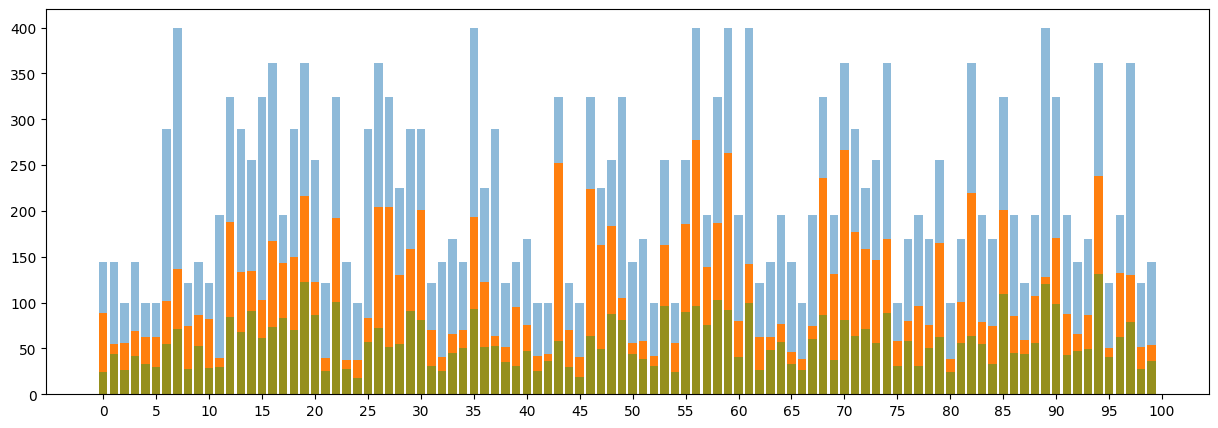

114.65


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.bar(list(range(len(evaluator.board_sizes))), evaluator.board_sizes, alpha=0.5)
plt.bar(list(range(len(evaluator.scores))), evaluator.scores)
plt.bar(list(range(len(evaluator.ans_points))), evaluator.ans_points, alpha=0.5)

plt.xticks(range(0, len(evaluator.scores)+1, 5))
plt.show()

print(sum(evaluator.scores) / len(evaluator.scores))